In [90]:
import os
import glob
import datetime

import numpy as np
import pandas as pd

import jax
import numpyro

import hssm
import arviz as az
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

In [91]:
jax.config.update('jax_platform_name', 'cpu')
hssm.set_floatX("float32")
numpyro.set_host_device_count(14)

Setting PyTensor floatX type to float32.
Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


# import fitted data

In [3]:
query = "SELECT * FROM summaries"
conn = sqlite3.connect("hssm_fits.db")

In [4]:
df = pd.read_sql_query(query, conn)

In [9]:
df

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
0,v,0.513,0.174,0.213,0.866,0.010,0.007,312.0,261.0,1.01,935
1,t,0.637,0.060,0.516,0.728,0.004,0.003,232.0,402.0,1.01,935
2,a,1.004,0.078,0.860,1.140,0.005,0.003,294.0,491.0,1.01,935
3,z,0.506,0.048,0.408,0.588,0.002,0.002,498.0,339.0,1.00,935
4,v,0.634,0.150,0.347,0.903,0.008,0.005,396.0,539.0,1.01,1062
...,...,...,...,...,...,...,...,...,...,...,...
1367,a,1.159,0.066,1.051,1.283,0.004,0.003,373.0,465.0,1.01,1085
1368,v,0.483,0.144,0.229,0.765,0.006,0.004,619.0,537.0,1.00,1111
1369,z,0.425,0.041,0.351,0.502,0.002,0.001,589.0,587.0,1.00,1111
1370,t,0.464,0.047,0.373,0.541,0.004,0.003,177.0,244.0,1.02,1111


# set up simulator

In [27]:
def get_fitted_parameters(df, participant_id):
    subset = df[df['participant_id'] == participant_id]
    v = subset[subset['param'] == 'v']['mean'].values[0]
    a = subset[subset['param'] == 'a']['mean'].values[0]
    z = subset[subset['param'] == 'z']['mean'].values[0]
    t = subset[subset['param'] == 't']['mean'].values[0]
    return v, a, z, t

In [29]:
def simulate_participant(participant_id, df, size=300):
    v, a, z, t = get_fitted_parameters(df, participant_id)
    v = np.repeat(v, size)          # drift rate
    a = a                           # boundary
    z = z                           # starting point
    t = t                           # non-decision time
    true_values = np.column_stack([v, np.repeat([[a, z, t]], size, axis=0)])

    dataset = hssm.simulate_data(
        model="ddm",
        theta=true_values,
        size=1,
    )

    dataset["participant_id"] = str(participant_id)
    return dataset

In [28]:
get_fitted_parameters(df, 1111)

(0.483, 1.06, 0.425, 0.464)

In [30]:
participant_ids = df['participant_id'].unique()

In [43]:
combined = pd.DataFrame()

for part in participant_ids:
    print(f"Simulating participant {part}")
    simulated_data = simulate_participant(part, df, size=300)
    combined = pd.concat([combined, simulated_data], ignore_index=True)

Simulating participant 935
Simulating participant 1062
Simulating participant 1081
Simulating participant 1109
Simulating participant 832
Simulating participant 867
Simulating participant 871
Simulating participant 957
Simulating participant 1036
Simulating participant 1039
Simulating participant 763
Simulating participant 794
Simulating participant 810
Simulating participant 936
Simulating participant 1011
Simulating participant 1028
Simulating participant 1080
Simulating participant 726
Simulating participant 728
Simulating participant 749
Simulating participant 751
Simulating participant 776
Simulating participant 791
Simulating participant 796
Simulating participant 818
Simulating participant 831
Simulating participant 872
Simulating participant 878
Simulating participant 883
Simulating participant 886
Simulating participant 887
Simulating participant 893
Simulating participant 931
Simulating participant 934
Simulating participant 948
Simulating participant 962
Simulating participa

In [48]:
combined

,rt,response,participant_id
0,2.367025,1.0,935
1,2.866021,-1.0,935
2,4.369912,1.0,935
3,1.178997,1.0,935
4,2.413027,-1.0,935
...,...,...,...
102895,1.682001,1.0,1111
102896,1.836008,1.0,1111
102897,1.390992,1.0,1111
102898,0.825999,1.0,1111


# real data

In [128]:
data = pd.read_csv('hssm_exp4_data.csv')

In [129]:
data

,response,rt,participant_id
0,0,1.4546,708
1,0,2.0167,708
2,1,0.9597,708
3,1,0.9102,708
4,0,1.0218,708
...,...,...,...
26508,1,1.3294,1113
26509,1,1.5069,1113
26510,1,1.3452,1113
26511,0,2.3210,1113


In [130]:
data.rt.max()

23.0865

In [131]:
data.participant_id.nunique()

343

In [132]:
26513/343

77.29737609329446

In [133]:
def plot_rt_distributions(data, responses=[0, 1], quantiles=[0.25, 0.5, 0.75], title="RT Distributions"):
    rt_correct = data.loc[data["response"] == responses[1], "rt"].values
    rt_error   = data.loc[data["response"] == responses[0], "rt"].values

    x = np.linspace(0, rt_correct.max(), 500)

    kde_c = gaussian_kde(rt_correct)
    kde_e = gaussian_kde(rt_error)

    yc = kde_c(x)
    ye = kde_e(x)

    fig, ax = plt.subplots(figsize=(6, 4))

    # Correct (top)
    ax.fill_between(x, 0, yc, color="0.7")
    ax.plot(x, yc, color="black")

    # Error (bottom, mirrored)
    ax.fill_between(x, 0, -ye, color="0.7")
    ax.plot(x, -ye, color="black")

    # Zero line
    ax.axhline(0, color="black", lw=0.8)

    # --- Quantile ticks ---
    q_correct = np.quantile(rt_correct, quantiles)
    q_error   = np.quantile(rt_error, quantiles)

    tick_height = 0.25 * max(yc.max(), ye.max())

    for q in q_correct:
        ax.plot([q, q], [0, tick_height], color="black", lw=1)

    for q in q_error:
        ax.plot([q, q], [0, -tick_height], color="black", lw=1)
    # ----------------------

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Density")

    ax.set_yticks([yc.max(), -ye.max()])
    ax.set_yticklabels(["Correct RTs", "Error RTs"])

    plt.title(title)

    plt.tight_layout()
    plt.show()

    print("Accuracy: ", len(rt_correct) / (len(rt_correct) + len(rt_error)))


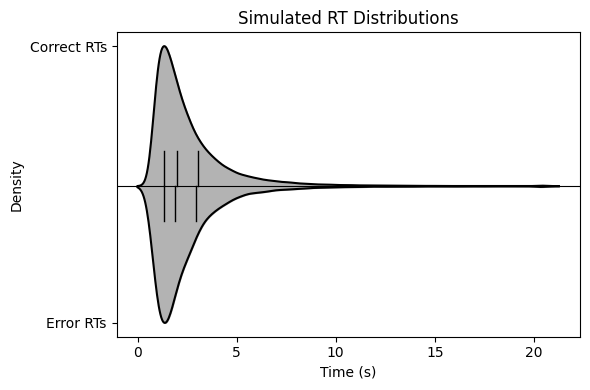

Accuracy:  0.7618658892128279


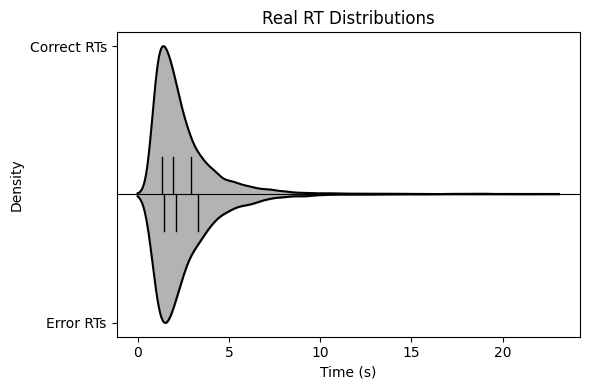

Accuracy:  0.7408818315543318


In [134]:
plot_rt_distributions(combined, responses=[-1, 1], title="Simulated RT Distributions")
plot_rt_distributions(data, responses=[0, 1], title="Real RT Distributions")

In [138]:
def plot_rt_distributions_ppc(
    data, sim_data,
    responses=((0, 1), (-1, 1)),
    quantiles=[0.25, 0.5, 0.75],
    title="RT Distributions (PPC)"
):
    (err_d, cor_d), (err_s, cor_s) = responses

    # --- empirical ---
    rt_c = data.loc[data["response"] == cor_d, "rt"].values
    rt_e = data.loc[data["response"] == err_d, "rt"].values

    # --- simulated ---
    rt_c_sim = sim_data.loc[sim_data["response"] == cor_s, "rt"].values
    rt_e_sim = sim_data.loc[sim_data["response"] == err_s, "rt"].values

    x = np.linspace(
        0,
        max(rt_c.max(), rt_c_sim.max()),
        500
    )

    yc = gaussian_kde(rt_c)(x)
    ye = gaussian_kde(rt_e)(x)
    yc_sim = gaussian_kde(rt_c_sim)(x)
    ye_sim = gaussian_kde(rt_e_sim)(x)

    fig, ax = plt.subplots(figsize=(6, 4))

    # data
    ax.fill_between(x, 0, yc, alpha=0.3)
    ax.plot(x, yc, lw=2, label="Correct (data)")

    ax.fill_between(x, 0, -ye, alpha=0.3)
    ax.plot(x, -ye, lw=2, label="Error (data)")

    # sim
    ax.plot(x, yc_sim, lw=2, ls="--", label="Correct (sim)")
    ax.plot(x, -ye_sim, lw=2, ls="--", label="Error (sim)")

    ax.axhline(0, color="black", lw=0.8)

    # quartiles
    h = 0.25 * max(yc.max(), ye.max())

    for q in np.quantile(rt_c, quantiles):
        ax.plot([q, q], [0, h], lw=1)

    for q in np.quantile(rt_c_sim, quantiles):
        ax.plot([q, q], [0, h], lw=1, ls="--")

    for q in np.quantile(rt_e, quantiles):
        ax.plot([q, q], [0, -h], lw=1)

    for q in np.quantile(rt_e_sim, quantiles):
        ax.plot([q, q], [0, -h], lw=1, ls="--")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Density")
    ax.set_yticks([yc.max(), -ye.max()])
    ax.set_yticklabels(["Correct RTs", "Error RTs"])

    ax.legend(frameon=False)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

    print("Accuracy (data):", len(rt_c) / (len(rt_c) + len(rt_e)))
    print("Accuracy (sim): ", len(rt_c_sim) / (len(rt_c_sim) + len(rt_e_sim)))


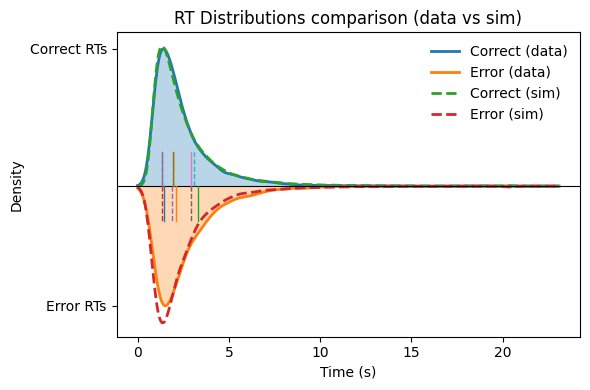

Accuracy (data): 0.7408818315543318
Accuracy (sim):  0.7618658892128279


In [140]:
plot_rt_distributions_ppc(data, combined, title="RT Distributions comparison (data vs sim)")

# new sim with same trial amount

In [136]:
combined_2 = pd.DataFrame()

for part in participant_ids:
    print(f"Simulating participant {part}")
    simulated_data = simulate_participant(part, df, size=80)
    combined_2 = pd.concat([combined_2, simulated_data], ignore_index=True)

Simulating participant 935
Simulating participant 1062
Simulating participant 1081
Simulating participant 1109
Simulating participant 832
Simulating participant 867
Simulating participant 871
Simulating participant 957
Simulating participant 1036
Simulating participant 1039
Simulating participant 763
Simulating participant 794
Simulating participant 810
Simulating participant 936
Simulating participant 1011
Simulating participant 1028
Simulating participant 1080
Simulating participant 726
Simulating participant 728
Simulating participant 749
Simulating participant 751
Simulating participant 776
Simulating participant 791
Simulating participant 796
Simulating participant 818
Simulating participant 831
Simulating participant 872
Simulating participant 878
Simulating participant 883
Simulating participant 886
Simulating participant 887
Simulating participant 893
Simulating participant 931
Simulating participant 934
Simulating participant 948
Simulating participant 962
Simulating participa

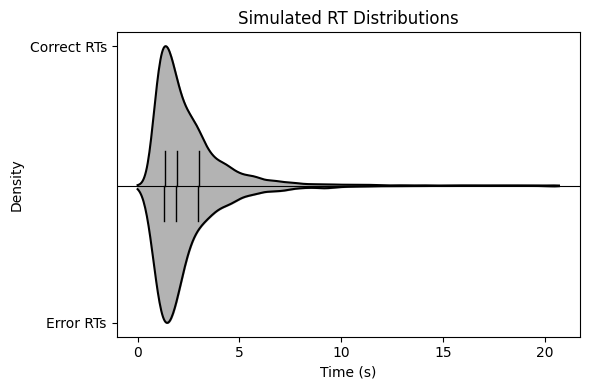

Accuracy:  0.7885568513119533


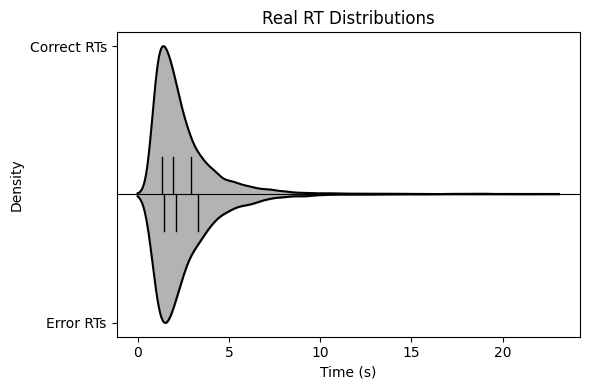

Accuracy:  0.7408818315543318


In [137]:
plot_rt_distributions(combined_2, responses=[-1, 1], title="Simulated RT Distributions")
plot_rt_distributions(data, responses=[0, 1], title="Real RT Distributions")

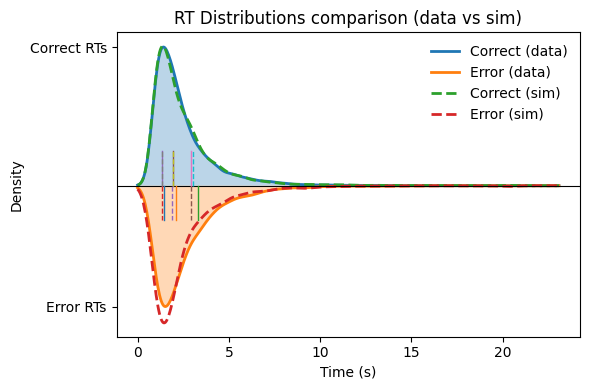

Accuracy (data): 0.7408818315543318
Accuracy (sim):  0.7885568513119533


In [141]:
plot_rt_distributions_ppc(data, combined_2, title="RT Distributions comparison (data vs sim)")